<a href="https://colab.research.google.com/github/jeshwanthhhh-ux/data-cleaning-and-preprocessing/blob/main/chapter_appendix-tools-for-deep-learning/jupyter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("Telco churn.csv")

# Remove Customer ID
df.drop('customerID', axis=1, inplace=True)

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_2098/3365489600.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


Exploratory data analysis


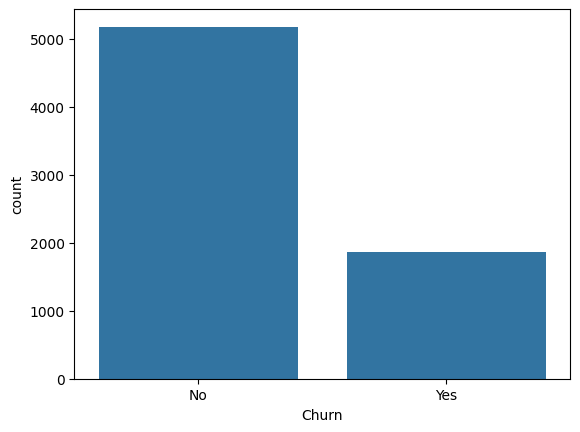

In [3]:
sns.countplot(x='Churn', data=df)
plt.show()

Contract vs Churn

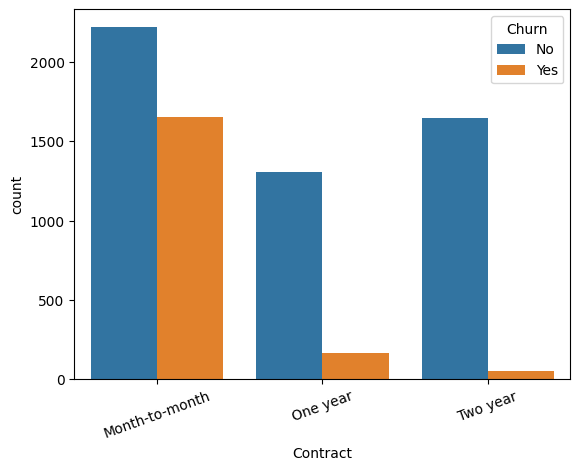

In [4]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=20)
plt.show()

Tenure vs Churn

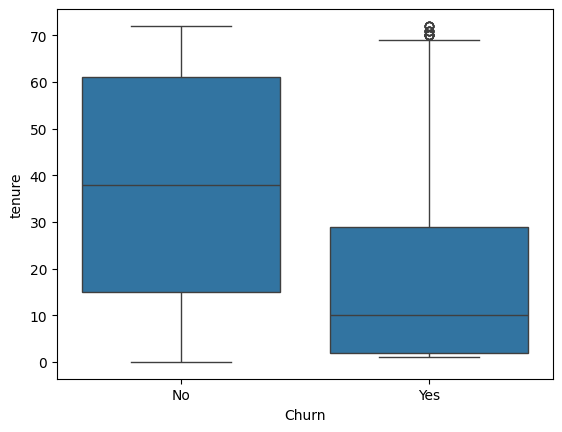

In [5]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.show()

Monthly Charges vs Churn

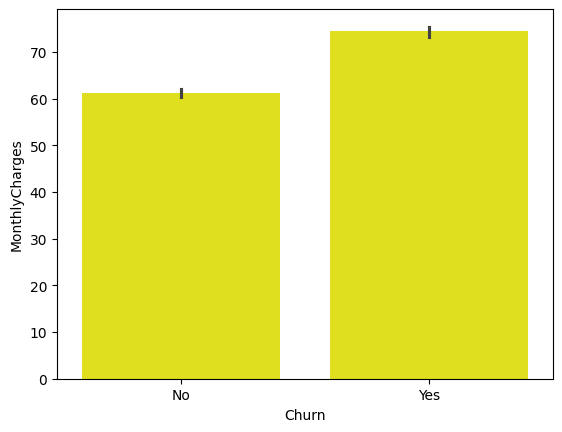

In [14]:
sns.barplot(x='Churn', y='MonthlyCharges', data=df, color='yellow')
plt.show()

Data Preprocessing

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

Split Data

In [16]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Train Model

In [17]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Evaluate Model

In [18]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7955997161107168
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1036
           1       0.66      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.74      0.69      0.71      1409
weighted avg       0.78      0.80      0.78      1409



Feature Importance

In [19]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

print(
    importance.sort_values(
        by='Importance',
        ascending=False
    ).head(10)
)

            Feature  Importance
18     TotalCharges    0.189992
17   MonthlyCharges    0.177867
4            tenure    0.157428
14         Contract    0.077357
16    PaymentMethod    0.050379
8    OnlineSecurity    0.047432
11      TechSupport    0.044190
0            gender    0.028117
9      OnlineBackup    0.027067
7   InternetService    0.026444
